# Bays (2014) Figure 1 Equivalence - Metric Heatmaps

**Key design:**
- `Population` class (`core.population`) handles encode/decode
- Circular stats (`circular_variance_fisher`, `circular_kurtosis_fisher`) live in `core.metrics`
- Single `MODEL` knob (`gp` / `vm` / `bays`)
- Analysis helpers live in core modules; the notebook defines none inline


#### 💾 Simulation Cache

The expensive simulation cell (the multi-set-size heatmap) saves its output to `./_sim_cache/` keyed on a hash of all relevant parameters (M, N_THETA, N_TRIALS, grid params, MODEL, seeds, …).

**Workflow for re-running this notebook:**

1. The first run populates the cache (slow).
2. Subsequent runs — including kernel restarts — skip the simulation and just load the arrays from disk (fast). All downstream plotting / analysis cells can then be edited and re-run in seconds.
3. If you change any simulation parameter (e.g. `M`, `N_TRIALS`, `MODEL`), the cache key changes automatically and the affected cell recomputes.
4. To force a fresh recompute without changing parameters, set `FORCE_RECOMPUTE = True` in the imports cell, or delete the relevant `.npz` file in `_sim_cache/`.
5. The helper `list_cache()` (called automatically at the top) prints what's currently stored.

**What's cached:**

| Cell | Cache name | Contents |
|------|------------|----------|
| Multi-set-size heatmap | `multi_heatmap` | per-`l` `var`/`kur`/`exp` grids |


#### Environment, Bays `Population` import & simulation cache

In [45]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import hashlib
import json as _json
import os

# ---- Import the Bays population model (encode -> DN -> spike -> ML decode) ----
from core.population import Population

print(f"Project root: {PROJECT_ROOT}")

# ============================================================
# Output directory for this run's deliverable results
# ============================================================
# A fresh timestamped folder under the project result_data tree.
# Figures (and any saved arrays) for this run are written here so
# successive runs never overwrite each other. This is separate from
# the _sim_cache/ below, which is the hash-keyed recompute cache.
import datetime
RESULT_BASE    = Path(PROJECT_ROOT) / 'experiments' / 'bays_2014' / 'result_data'
EXPERIMENT_TAG = 'experiment_1'
# OUTPUT_DIR is built in the experiment-control section below, once
# M / DISTRIBUTION / MODEL are known, so the folder name encodes the run.

# ============================================================
# Simulation cache infrastructure
# ============================================================
# Expensive simulation cells (the main heatmap and the multi-set-size
# heatmap) save their results to disk keyed on the parameters used.
# Downstream plotting / analysis cells then load these arrays and run
# instantly. To force a fresh recompute, set FORCE_RECOMPUTE = True
# below, or delete the relevant .npz file in CACHE_DIR.

CACHE_DIR = Path.cwd() / "_sim_cache"
CACHE_DIR.mkdir(exist_ok=True)

FORCE_RECOMPUTE = False   # set True to ignore cache and recompute everything

def _hash_key(params: dict) -> str:
    """Deterministic short hash of a dict of parameters."""
    blob = _json.dumps(params, sort_keys=True, default=str).encode()
    return hashlib.md5(blob).hexdigest()[:12]

def cache_path(name: str, params: dict) -> Path:
    """Return the .npz cache path for a named computation + its params."""
    return CACHE_DIR / f"{name}__{_hash_key(params)}.npz"

def load_cache(name: str, params: dict):
    """Return dict of arrays if cache hit, else None."""
    if FORCE_RECOMPUTE:
        return None
    p = cache_path(name, params)
    if not p.exists():
        return None
    try:
        with np.load(p, allow_pickle=True) as data:
            return {k: data[k] for k in data.files}
    except Exception as e:
        print(f"  [cache] failed to load {p.name}: {e}")
        return None

def save_cache(name: str, params: dict, arrays: dict):
    """Save arrays to cache with embedded params metadata."""
    p = cache_path(name, params)
    # Stash params alongside the arrays for traceability.
    payload = dict(arrays)
    payload["_params_json"] = np.array(_json.dumps(params, default=str))
    np.savez_compressed(p, **payload)
    print(f"  [cache] saved {p.name}  ({p.stat().st_size / 1e6:.2f} MB)")

def list_cache():
    """Print all cache entries with their parameter hash."""
    files = sorted(CACHE_DIR.glob("*.npz"))
    if not files:
        print(f"  [cache] (empty) {CACHE_DIR}")
        return
    print(f"  [cache] {CACHE_DIR}:")
    for f in files:
        size_mb = f.stat().st_size / 1e6
        print(f"    {f.name}  ({size_mb:.2f} MB)")

list_cache()


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1
Output dir:   /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_1_20260725_121106
  [cache] /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/_sim_cache:
    multi_heatmap__8ce2174560f4.npz  (0.04 MB)


#### Circular-error metrics (imported from `core.metrics`)

In [46]:
# Circular-error metrics now live in core.metrics (single source of truth).
# See core/metrics.py for the Fisher (1995) definitions used by Bays (2014).
from core.metrics import circular_variance_fisher, circular_kurtosis_fisher


#### Sanity check — `Population.run_trials` is vectorised

In [47]:
import inspect
src = inspect.getsource(Population.run_trials)
print("Vectorised" if "log_r_pre" in src else "Sequential (OLD)")

Vectorised


### Parameters

**Mapping:** Bays's tuning f = 1/omega gives omega = lambda^2, so lambda = sqrt(omega).
- Small omega (broad tuning) -> small lambda
- Large omega (narrow tuning) -> large lambda

## GP Experiment Control

Three knobs govern every population built in this notebook (the L>1 multi-set-size sweep and the diagnostics below). Flipping any of them changes the simulation-cache key, so a matching cached result is loaded or a fresh one is computed automatically.

**`M`** is the population size. Suggested values: `100` (fast, primary reference), `1000` (default), `10000` (large-population asymptotic).

**`DISTRIBUTION`** chooses how lengthscales are sampled across locations inside the GP / VM forward model: `'folded_normal'`, `'gamma'`, or `'M_sparse_broad'`. It affects the `gp` and `vm` models; the `bays` model uses parametric von Mises tuning and ignores it.

**`MODEL`** selects the encoder: `'gp'` (Gaussian-process tuning, width = √ω), `'vm'` (von Mises tuning, width = ω), or `'bays'` (the parametric Bays baseline, homogeneous, single location with the γ/l activity-cap shortcut).

`'M_sparse_broad'` is the multi-broad-location variant of `population.py`'s `sparse_broad` sampler — `N_HIGH` locations are drawn 'broad' and the rest 'sharp' (set `N_HIGH = 1` for the one-hot case). It is resolved to the underlying `sparse_broad` method via `_DISTRIBUTION_MAP` in the control cell below.

#### Experiment control — population size `M` & lengthscale sampler

In [48]:
# === GP EXPERIMENT CONTROL — set M and lengthscale sampler for this run ===
# Flags governing every GP Population built in this notebook. Cached
# heatmaps automatically pick this up via the cache key, so flipping
# either flag forces a recompute (or loads a matching cached result).

M            = 1000               # 100 / 1000 / 10000
DISTRIBUTION = 'folded_normal'   # 'folded_normal' | 'gamma' | 'M_sparse_broad'
MODEL        = 'gp'              # 'gp' | 'vm' | 'bays'  (encoder / tuning model)

assert DISTRIBUTION in ('folded_normal', 'gamma', 'M_sparse_broad'), (
    f"DISTRIBUTION must be one of 'folded_normal', 'gamma', "
    f"'M_sparse_broad', got {DISTRIBUTION!r}"
)
assert MODEL in ('gp', 'vm', 'bays'), f"MODEL must be gp/vm/bays, got {MODEL!r}"

# --- Sparse-broad knob -------------------------------------------------
# 'M_sparse_broad' is the multi-broad-location variant of population.py's
# 'sparse_broad' sampler: N_HIGH locations are designated 'broad'
# (drawn around base_lengthscale * high_multiplier) and the rest 'sharp'.
# N_HIGH = 1 reduces to the one-hot sparse_broad; N_HIGH > 1 is the k-hot
# ('M' = multiple) generalisation.
N_HIGH = 3

# --- Resolve the notebook-facing label to the actual population.py -----
# method string + any extra constructor kwargs. folded_normal / gamma
# pass straight through; M_sparse_broad maps onto the 'sparse_broad'
# method with n_high.
#
# NOTE: if your population.py registers the literal method string
# 'M_sparse_broad' (rather than 'sparse_broad' + n_high), change the
# mapping below to: 'M_sparse_broad': ('M_sparse_broad', {}). Likewise,
# drop the n_high kwarg if Population() does not forward it.
_DISTRIBUTION_MAP = {
    'folded_normal':  ('folded_normal', {}),
    'gamma':          ('gamma',         {}),
    'M_sparse_broad': ('sparse_broad',  {'n_high': N_HIGH}),
}
GP_METHOD, GP_METHOD_KWARGS = _DISTRIBUTION_MAP[DISTRIBUTION]

print(f'=== GP experiment control ===')
print(f'  M                = {M}')
print(f'  MODEL            = {MODEL!r}')
print(f'  DISTRIBUTION     = {DISTRIBUTION!r}')
print(f'  -> GP_METHOD     = {GP_METHOD!r}')
print(f'  -> extra kwargs  = {GP_METHOD_KWARGS}')


=== GP experiment control ===
  M                = 1000
  DISTRIBUTION     = 'folded_normal'
  -> GP_METHOD     = 'folded_normal'
  -> extra kwargs  = {}


#### Simulation grid — width ω × gain γ

In [49]:
# M is set by the experiment-control cell above.
N_THETA = 256      # Orientation grid resolution
N_TRIALS = 10000   # 10k with vectorisation
T_D = 0.1          # Decoding window (s)
SIGMA_SQ = 1e-6    # Semi-saturation constant

# ---- Width (x-axis): omega = lambda^2 ----
OMEGA_RANGE = (0.125, 2.5)
LAMBDA_RANGE = (np.sqrt(OMEGA_RANGE[0]),    # 0.354 (broad, low omega)
                np.sqrt(OMEGA_RANGE[1]))     # 1.581 (narrow, high omega)

# ---- Gain (y-axis): gamma_total = gamma_mean * M ----
GAMMA_TOTAL_RANGE = (0.25, 4096)   # Hz, total population gain
GAMMA_RANGE = (GAMMA_TOTAL_RANGE[0] / M,
               GAMMA_TOTAL_RANGE[1] / M)

N_GRID = 20

# Build grids
lambdas = np.logspace(np.log2(LAMBDA_RANGE[0]), np.log2(LAMBDA_RANGE[1]), N_GRID, base=2)
omegas = lambdas**2

gammas = np.logspace(np.log2(GAMMA_RANGE[0]), np.log2(GAMMA_RANGE[1]), N_GRID, base=2)
gammas_total = gammas * M

print(gammas_total)


print(f"Grid: {N_GRID}x{N_GRID}, {N_TRIALS:,} trials each")
print(f"lambda range:       [{LAMBDA_RANGE[0]:.3f}, {LAMBDA_RANGE[1]:.3f}]")
print(f"omega = lambda^2:   [{omegas[0]:.3f}, {omegas[-1]:.3f}]")
print(f"gamma_total range:  [{gammas_total[0]:.2f}, {gammas_total[-1]:.1f}] Hz")


[2.50000000e-01 4.16631003e-01 6.94325571e-01 1.15711024e+00
 1.92835200e+00 3.21364491e+00 5.35561640e+00 8.92526334e+00
 1.48741657e+01 2.47881543e+01 4.13100543e+01 6.88441975e+01
 1.14730508e+02 1.91201147e+02 3.18641303e+02 5.31023383e+02
 8.84963219e+02 1.47481245e+03 2.45781037e+03 4.09600000e+03]
Grid: 20x20, 10,000 trials each
lambda range:       [0.354, 1.581]
omega = lambda^2:   [0.125, 2.500]
gamma_total range:  [0.25, 4096.0] Hz


#### Encoder toggle & reference Bays operating point

In [50]:
# ---- Encoder / run configuration ----
# MODEL (gp / vm / bays) is set in the experiment-control cell above.
SEED = 42

# ---- Reference Bays operating point (group-mean ML fit, Bays 2014 Fig 2b) ----
# The fixed (omega, gamma) at which the equivalence test is run. Nothing here
# is fitted -- figure 1 uses Bays's published values directly.
GAMMA_TOTAL_FITTED = 119.0   # Hz -- total population gain
OMEGA_FITTED       = 0.52    # tuning width (group mean)
SET_SIZES          = [1, 2, 4, 8]
gamma_fitted = GAMMA_TOTAL_FITTED / M

# ---- Output directory for this run's deliverables --------------------
#   result_data / experiment_1 / <date> / <distribution>_<M>_<model> / <time>
# Mirrors the Experiment 2/3 scheme so the folder name is self-describing.
_date = datetime.datetime.now().strftime('%Y%m%d')
_time = datetime.datetime.now().strftime('%H%M%S')
OUTPUT_DIR = (RESULT_BASE / EXPERIMENT_TAG / _date /
              f'{DISTRIBUTION}_{M}_{MODEL}' / _time)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"MODEL={MODEL}, SEED={SEED}")
print(f"gamma_total = {GAMMA_TOTAL_FITTED} Hz  (gamma_mean = {gamma_fitted:.6f} Hz/neuron)")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

Encoder: TUNING=gp  (BAYS=False),  SEED=42
gamma_total = 119.0 Hz  (gamma_mean = 0.119000 Hz/neuron)
1000 folded_normal


## L > 1, HeatMap Creation

**Goal:** Test whether the Bays equivalence (l items at γ ≡ 1 item at γ/l) holds for the GP model.

**Design:**
- **4 rows** (l = 1, 2, 4, 8) × **3 columns** (variance, kurtosis, exponent)
- Each row is a full (ω, γ) heatmap computed by running the **actual** multi-item pipeline at that set size
- All rows use the **same underlying population** (same GP samples) per ω column
- **Row 1 (l=1):** horizontal lines at γ\_eff = γ\_total/l mark the Bays predictions
- **Rows 2–4:** single black line at γ\_total = 114.73 Hz (grid index 12)

**Quantitative test (at γ\_total = 114.73 Hz):**
- **Vector A** (Bays prediction): l=1 heatmap row at γ\_eff = γ\_total/l
- **Vector B** (actual): l-th heatmap row at γ\_total
- Compare via Pearson correlation and mean absolute error

In Bays's model, A = B exactly. In the GP model, deviations reveal how mixed selectivity and shared populations create a more nuanced resource division.

#### Compute per-set-size (ω, γ) heatmaps  ·  covers l = 1, 2, 4, 8

In [51]:
# ---- Multi-set-size heatmap computation ----
# Recomputes ALL set sizes with consistent populations (L=8 for GP, L=1 for Bays)

from tqdm.notebook import tqdm

N_LOCATIONS_HEATMAP = 8
SET_SIZES_HEATMAP = [1, 2, 4, 8]
GAMMA_REF_IDX = 12  # γ_total = 114.73 Hz (exact grid point)
SEED_MULTI_HEATMAP = 42

print(f"Reference γ_total = {gammas_total[GAMMA_REF_IDX]:.2f} Hz (index {GAMMA_REF_IDX})")
print(f"Set sizes: {SET_SIZES_HEATMAP}")
print(f"Grid: {N_GRID}×{N_GRID}, {N_TRIALS:,} trials per pixel")
print(f"Model: {MODEL}")
print()

# Cache key for this computation.
_multi_params = {
    "M": M,
    "N_THETA": N_THETA,
    "N_TRIALS": N_TRIALS,
    "T_D": T_D,
    "SIGMA_SQ": SIGMA_SQ,
    "N_GRID": N_GRID,
    "OMEGA_RANGE": list(OMEGA_RANGE),
    "GAMMA_TOTAL_RANGE": list(GAMMA_TOTAL_RANGE),
    "MODEL": MODEL,
    "DISTRIBUTION": DISTRIBUTION,
    "GP_METHOD_KWARGS": GP_METHOD_KWARGS,
    "N_LOCATIONS_HEATMAP": N_LOCATIONS_HEATMAP,
    "SET_SIZES_HEATMAP": list(SET_SIZES_HEATMAP),
    "SEED_MULTI_HEATMAP": SEED_MULTI_HEATMAP,
}

_cached_multi = load_cache("multi_heatmap", _multi_params)

if _cached_multi is not None:
    print(f"  [cache HIT] multi_heatmap  (MODEL={MODEL})")
    heatmaps = {}
    for l in SET_SIZES_HEATMAP:
        heatmaps[l] = {
            "var": _cached_multi[f"l{l}_var"],
            "kur": _cached_multi[f"l{l}_kur"],
            "exp": _cached_multi[f"l{l}_exp"],
        }
    print(f"  Loaded heatmaps for set sizes {SET_SIZES_HEATMAP}")
else:
    print(f"  [cache MISS] multi_heatmap  (MODEL={MODEL}) — recomputing…")
    # Storage: heatmaps[l] = {'var': ..., 'kur': ..., 'exp': ...}
    heatmaps = {}

    t0_all = time.time()

    # Outer bar over set sizes
    for l in tqdm(SET_SIZES_HEATMAP, desc="set sizes", leave=True):
        var_grid_l = np.full((N_GRID, N_GRID), np.nan)
        kur_grid_l = np.full((N_GRID, N_GRID), np.nan)
        var_half_l = np.full((N_GRID, N_GRID), np.nan)

        t0_l = time.time()

        # Inner bar over omega columns; updates in place, one line per set size
        for i, omega in enumerate(
            tqdm(omegas, desc=f"  l={l}", leave=False)
        ):
            # Create population: same seed per omega column across all l values
            width_param = np.sqrt(omega) if MODEL == 'gp' else omega
            pop = Population(
                M, N_THETA, width_param,
                tuning_type=MODEL,
                n_locations=1 if MODEL == 'bays' else N_LOCATIONS_HEATMAP,
                seed=SEED_MULTI_HEATMAP + i * 1000,
                method=GP_METHOD, **GP_METHOD_KWARGS,
            )

            for j, gam in enumerate(gammas):
                # Different RNG seeds for different l values
                rng  = np.random.RandomState(
                    SEED_MULTI_HEATMAP + l * 100000 + i * N_GRID + j)
                rng2 = np.random.RandomState(
                    SEED_MULTI_HEATMAP + l * 100000 + i * N_GRID + j + N_GRID**2)

                if pop.L == 1:
                    # Bays (L=1): γ_eff = γ/l shortcut
                    errors = pop.run_trials(
                        N_TRIALS, gam / l, T_D,
                        set_size=1, sigma_sq=SIGMA_SQ, rng=rng)
                    errors_half = pop.run_trials(
                        N_TRIALS, gam / (2 * l), T_D,
                        set_size=1, sigma_sq=SIGMA_SQ, rng=rng2)
                else:
                    # GP (L>1): full multi-item pipeline
                    errors = pop.run_trials(
                        N_TRIALS, gam, T_D,
                        set_size=l, sigma_sq=SIGMA_SQ, rng=rng)
                    errors_half = pop.run_trials(
                        N_TRIALS, gam / 2, T_D,
                        set_size=l, sigma_sq=SIGMA_SQ, rng=rng2)

                var_grid_l[j, i] = circular_variance_fisher(errors)
                kur_grid_l[j, i] = circular_kurtosis_fisher(errors)
                var_half_l[j, i] = circular_variance_fisher(errors_half)

        # Compute exponent grid
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_l = np.where(var_half_l > 1e-15, var_grid_l / var_half_l, np.nan)
            exp_grid_l = np.where(ratio_l > 0, np.log2(ratio_l), np.nan)

        heatmaps[l] = {'var': var_grid_l, 'kur': kur_grid_l, 'exp': exp_grid_l}

        elapsed_total = time.time() - t0_all
        tqdm.write(
            f"  l={l} done in {time.time() - t0_l:.0f}s  "
            f"(total elapsed: {elapsed_total:.0f}s)"
        )

    print(f"\nAll set sizes done in {time.time() - t0_all:.0f}s")

    # Save all set sizes into one .npz
    _save_payload = {}
    for l in SET_SIZES_HEATMAP:
        _save_payload[f"l{l}_var"] = heatmaps[l]["var"]
        _save_payload[f"l{l}_kur"] = heatmaps[l]["kur"]
        _save_payload[f"l{l}_exp"] = heatmaps[l]["exp"]
    save_cache("multi_heatmap", _multi_params, _save_payload)



Reference γ_total = 114.73 Hz (index 12)
Set sizes: [1, 2, 4, 8]
Grid: 20×20, 10,000 trials per pixel
Tuning mode: gp

  [cache MISS] multi_heatmap  (TUNING=gp) — recomputing…


set sizes:   0%|          | 0/4 [00:00<?, ?it/s]

  l=1:   0%|          | 0/20 [00:00<?, ?it/s]

  l=1 done in 1971s  (total elapsed: 1971s)


  l=2:   0%|          | 0/20 [00:00<?, ?it/s]

  l=2 done in 3351s  (total elapsed: 5322s)


  l=4:   0%|          | 0/20 [00:00<?, ?it/s]

  l=4 done in 2126s  (total elapsed: 7448s)


  l=8:   0%|          | 0/20 [00:00<?, ?it/s]

  l=8 done in 10817s  (total elapsed: 18264s)

All set sizes done in 18264s
  [cache] saved multi_heatmap__b0a7ac9aa426.npz  (0.04 MB)
1000 folded_normal


### L > 1, HeatMap Plotting

- **Row 1 (l=1):** single-item heatmap + horizontal lines at γ/l for l=1,2,4,8
- **Rows 2–4:** actual multi-item heatmaps + black line at γ\_total = 114.73 Hz
- Bays's prediction: row l at the black line should match row 1 at the l-th horizontal line

#### Render the 4×3 heatmap figure

Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_1_20260725_121106/fig1_multisetsize_gp_M1000_folded_normal.png


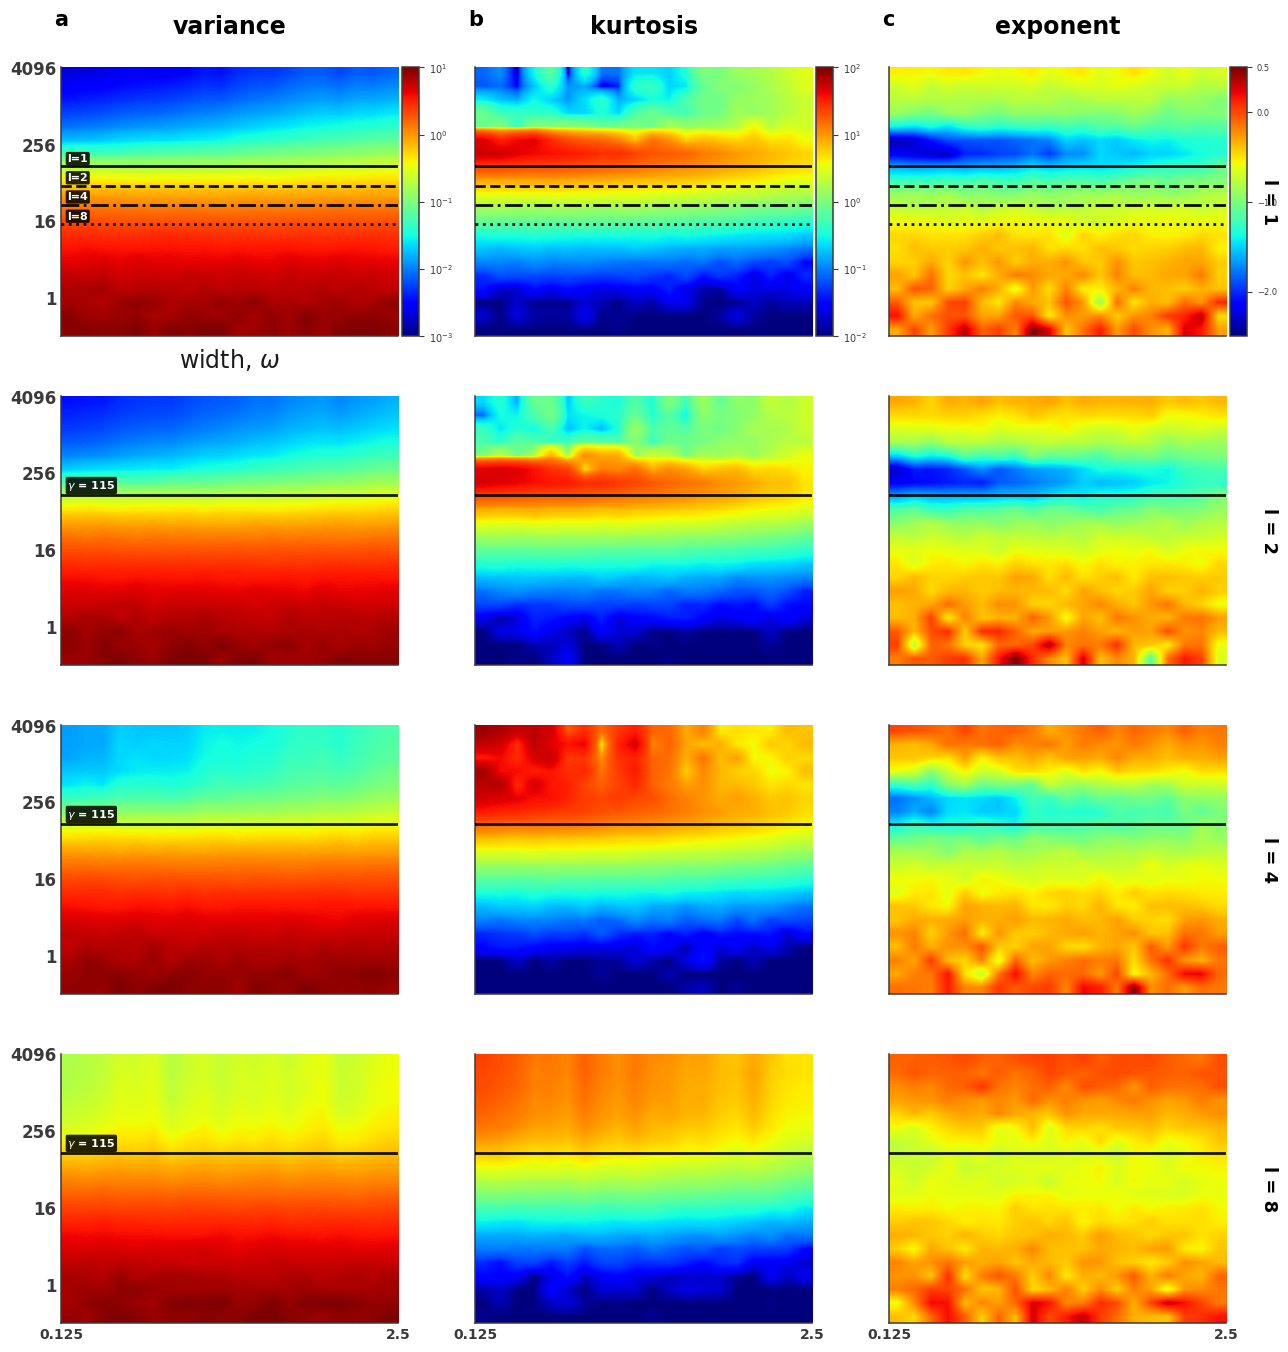

l=1: min=-2.350, max=0.488
l=2: min=-2.305, max=0.517
l=4: min=-1.785, max=0.482
l=8: min=-0.759, max=0.324
var
  l=1: min=0.002154, max=11.9
  l=2: min=0.003619, max=11.8
  l=4: min=0.01323, max=12.67
  l=8: min=0.1718, max=13.3
kur
  l=1: min=-0.08572, max=52.65
  l=2: min=-0.01148, max=50.05
  l=4: min=-0.02188, max=79.65
  l=8: min=-0.01533, max=23.11
var l=1: min=0.002154, any<=0: False, nans: False
var l=2: min=0.003619, any<=0: False, nans: False
var l=4: min=0.01323, any<=0: False, nans: False
var l=8: min=0.1718, any<=0: False, nans: False
kur l=1: min=-0.08572, any<=0: True, nans: False
kur l=2: min=-0.01148, any<=0: True, nans: False
kur l=4: min=-0.02188, any<=0: True, nans: False
kur l=8: min=-0.01533, any<=0: True, nans: False


In [52]:
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
# ---- 4-row × 3-column figure ----
ext = [
    np.log2(omegas[0]), np.log2(omegas[-1]),
    np.log2(gammas_total[0]), np.log2(gammas_total[-1]),
]

gamma_ref = gammas_total[GAMMA_REF_IDX]

VAR_VMIN, VAR_VMAX = 0.001, 10
KUR_VMIN, KUR_VMAX = 0.01,  100
EXP_VMIN, EXP_VMAX = -2.5, 0.5

# Explicit y-axis ticks: shown bold + larger, tick dashes removed.
Y_TICKS = np.array([1, 16, 256, 4096])
YTICK_FONTSIZE = 12          # bigger, like the reference
XTICK_FONTSIZE = 10

def fmt_ax_multi(ax, show_xticklabels, show_y, show_ylabel):
    ax.grid(False)
    # x: first/last value only, on bottom row only.
    ax.set_xticks([np.log2(omegas[0]), np.log2(omegas[-1])])
    ax.set_xticklabels(
        [f'{omegas[0]:g}', f'{omegas[-1]:g}'] if show_xticklabels else [],
        fontsize=XTICK_FONTSIZE, fontweight='bold')
    # y: left column only — bold, larger, no minus/dash tick marks.
    if show_y:
        yt = Y_TICKS[(Y_TICKS >= gammas_total[0] * 0.9) &
                     (Y_TICKS <= gammas_total[-1] * 1.1)]
        ax.set_yticks(np.log2(yt))
        ax.set_yticklabels([f'{v:g}' for v in yt],
                           fontsize=YTICK_FONTSIZE, fontweight='bold')
        if show_ylabel:
            ax.set_xlabel(r'width, $\omega$', fontsize=17)
    else:
        ax.set_yticks([])
    # Remove the little dash/tick marks on both axes — keep only the numbers.
    ax.tick_params(axis='both', length=0)

def add_cbar_slot(ax, im=None, log=False, tick_labelsize=7, ticks=None):
    """Reserve an identical colorbar slot on every panel. Fill only when im
    is given. `ticks` lets us thin out the exponent scale."""
    cax = make_axes_locatable(ax).append_axes('right', size='5%', pad=0.04)
    if im is None:
        cax.axis('off')
        return
    cbar = fig.colorbar(im, cax=cax)
    if log:
        cbar.ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
        cbar.ax.yaxis.set_minor_locator(mticker.NullLocator())
        cbar.ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    elif ticks is not None:
        cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=tick_labelsize)

overlay_styles = {1: '-', 2: '--', 4: '-.', 8: ':'}
OVERLAY_COLOR  = 'black'
COLUMN_LETTERS = ['a', 'b', 'c']

nrows = len(SET_SIZES_HEATMAP)
fig, axes = plt.subplots(nrows, 3, figsize=(13, 3.4 * nrows))

# key, vmin, vmax, title, is_log, cbar tick size, explicit cbar ticks
col_spec = [
    ('var', VAR_VMIN, VAR_VMAX, 'variance', True,  7, None),
    ('kur', KUR_VMIN, KUR_VMAX, 'kurtosis', True,  7, None),
    ('exp', EXP_VMIN, EXP_VMAX, 'exponent', False, 6, [0.5, 0, -1, -2]),  
]

for row_idx, l in enumerate(SET_SIZES_HEATMAP):
    is_bottom = (row_idx == nrows - 1)
    is_top    = (row_idx == 0)
    data = heatmaps[l]

    for col_idx, (key, vmin, vmax, title, is_log, cbtick, cbticks) in enumerate(col_spec):
        ax = axes[row_idx, col_idx]
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if is_log else None
        kw = dict(norm=norm) if is_log else dict(vmin=vmin, vmax=vmax)
        im = ax.imshow(np.clip(data[key], vmin, vmax),
                       origin='lower', aspect='auto', extent=ext,
                       cmap='jet', interpolation='bilinear', **kw)

        add_cbar_slot(ax, im=im if is_top else None,
                      log=is_log, tick_labelsize=cbtick, ticks=cbticks)

        fmt_ax_multi(ax, show_xticklabels=is_bottom,
                     show_y=(col_idx == 0), show_ylabel=is_top)

        if is_top:
            ax.text(-0.02, 1.14, COLUMN_LETTERS[col_idx],
                    transform=ax.transAxes, fontsize=15,
                    fontweight='bold', va='bottom', ha='left')
            ax.set_title(title, fontsize=17, fontweight='bold', pad=24)

    # ---- Overlay lines (all black) ----
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        if is_top:
            for ll in SET_SIZES_HEATMAP:
                g_eff = gamma_ref / ll
                if gammas_total[0] <= g_eff <= gammas_total[-1]:
                    y_pos = np.log2(g_eff)
                    ax.axhline(y=y_pos, color=OVERLAY_COLOR,
                               linestyle=overlay_styles[ll],
                               linewidth=2.0, alpha=0.95, zorder=5)
                    if col_idx == 0:
                        ax.text(ext[0] + 0.08, y_pos + 0.15, f'l={ll}',
                                color='white', fontsize=8, fontweight='bold',
                                va='bottom', ha='left', zorder=6,
                                bbox=dict(boxstyle='round,pad=0.15',
                                          fc=OVERLAY_COLOR, ec='none', alpha=0.85))
        else:
            y_pos = np.log2(gamma_ref)
            ax.axhline(y=y_pos, color=OVERLAY_COLOR, linestyle='-',
                       linewidth=2.0, alpha=0.9, zorder=5)
            if col_idx == 0:
                ax.text(ext[0] + 0.08, y_pos + 0.15,
                        f'$\\gamma$ = {gamma_ref:.0f}', color='white',
                        fontsize=8, fontweight='bold', va='bottom', ha='left',
                        zorder=6,
                        bbox=dict(boxstyle='round,pad=0.15',
                                  fc=OVERLAY_COLOR, ec='none', alpha=0.85))

    # Row identifier on the right (pad_inches below keeps it off the border)
    axes[row_idx, 2].text(
        1.10, 0.5, f'l = {l}',
        transform=axes[row_idx, 2].transAxes,
        fontsize=13, fontweight='bold', va='center', ha='left', rotation=-90)

plt.tight_layout()

_results_dir = OUTPUT_DIR
_l8_path = _results_dir / f'fig1_multisetsize_{MODEL}_M{M}_{DISTRIBUTION}.png'
plt.savefig(_l8_path, dpi=150, bbox_inches='tight', pad_inches=0.4)  # room for 'l' label
print(f'Saved {_l8_path}')
plt.show()
for l in SET_SIZES_HEATMAP:
    e = heatmaps[l]['exp']
    print(f'l={l}: min={np.nanmin(e):.3f}, max={np.nanmax(e):.3f}')
for key in ['var', 'kur']:
    print(key)
    for l in SET_SIZES_HEATMAP:
        d = heatmaps[l][key]
        print(f'  l={l}: min={np.nanmin(d):.4g}, max={np.nanmax(d):.4g}')
for key in ['var', 'kur']:
    for l in SET_SIZES_HEATMAP:
        d = heatmaps[l][key]
        print(f'{key} l={l}: min={np.nanmin(d):.4g}, any<=0: {(d<=0).any()}, nans: {np.isnan(d).any()}')

### Metric Calculation

**Does l items at γ ≡ 1 item at γ/l?**

For each set size l ∈ {2, 4, 8} at the reference γ\_total = 114.73 Hz:
- **Vector A** (Bays prediction): extract row from the l=1 heatmap at γ\_eff = γ\_total/l (nearest grid point)
- **Vector B** (actual GP result): extract row from the l-th heatmap at γ\_total

Both vectors have N\_GRID entries (one per ω). We compare them via:
1. **Pearson correlation** — do they have the same shape across ω?
2. **Mean absolute error** — how far apart are the actual values?

#### Equivalence analysis — predicted vs measured vectors

No optimizer runs here: (ω, γ) are fixed to Bays's published values, and the "fit" quality is quantified by Pearson ρ and relative MAE between the l=1 prediction and the multi-item measurement.

In [53]:
# ---- Quantitative equivalence test (Candidate A, interpolated) ----
#
# Bays equivalence: l items at γ_ref behaves like 1 item at γ_ref/l.
#
#   Prediction  (Bays):  heatmaps[1] interpolated at γ_eff = γ_ref / l
#   Measurement (GP):    heatmaps[l] row at γ_ref           (always same row)
#
# Both vectors are over omega (length N_GRID).
# We INTERPOLATE the prediction along the log-gain axis so we hit γ_ref/l
# exactly, instead of snapping to the nearest grid point.

from scipy.stats import pearsonr

gamma_ref = gammas_total[GAMMA_REF_IDX]
log2_gammas = np.log2(gammas_total)

print(f"Reference: γ_ref = {gamma_ref:.2f} Hz (grid index {GAMMA_REF_IDX})")
print(f"Model: {MODEL}")
print()


def interp_row_at_gain(grid, target_gain):
    """
    Linearly interpolate a heatmap (gamma × omega) along the log2-gain axis
    at `target_gain` Hz. Returns a length-N_GRID vector over omega.
    Linear-in-log2(gamma) matches how the gain grid was constructed.
    """
    target_log = np.log2(target_gain)
    if target_log <= log2_gammas[0]:
        return grid[0, :].copy()
    if target_log >= log2_gammas[-1]:
        return grid[-1, :].copy()
    j_hi = np.searchsorted(log2_gammas, target_log)
    j_lo = j_hi - 1
    w = (target_log - log2_gammas[j_lo]) / (log2_gammas[j_hi] - log2_gammas[j_lo])
    return (1 - w) * grid[j_lo, :] + w * grid[j_hi, :]


# Confirm the target γ_eff per set size and that interpolation lands on it.
target_gains = {}
for l in [2, 4, 8]:
    g_eff = gamma_ref / l
    target_gains[l] = g_eff
    print(f"  l={l}: γ_eff = γ_ref/l = {g_eff:.3f} Hz "
          f"(interpolated, no grid snapping)")
print()

quantities = [
    ('variance', 'var'),
    ('kurtosis', 'kur'),
    ('exponent', 'exp'),
]

results_table = []

for l in [2, 4, 8]:
    g_eff = target_gains[l]

    row_result = {'l': l, 'g_eff': g_eff}

    for q_name, q_key in quantities:
        # PREDICTION: heatmaps[1] interpolated at γ_eff = γ_ref/l
        vec_pred = interp_row_at_gain(heatmaps[1][q_key], g_eff)
        # MEASUREMENT: heatmaps[l] at γ_ref (no interpolation needed)
        vec_meas = heatmaps[l][q_key][GAMMA_REF_IDX, :]

        valid = np.isfinite(vec_pred) & np.isfinite(vec_meas)
        vp = vec_pred[valid]
        vm = vec_meas[valid]

        if len(vp) >= 3:
            corr, p_val = pearsonr(vp, vm)
            mae  = np.mean(np.abs(vp - vm))
            rmae = mae / (np.mean(np.abs(vp)) + 1e-15)
        else:
            corr, p_val, mae, rmae = np.nan, np.nan, np.nan, np.nan

        row_result[f'{q_name}_corr'] = corr
        row_result[f'{q_name}_pval'] = p_val
        row_result[f'{q_name}_mae']  = mae
        row_result[f'{q_name}_rmae'] = rmae
        row_result[f'{q_name}_pred'] = vec_pred
        row_result[f'{q_name}_meas'] = vec_meas

    results_table.append(row_result)

# ---- Print table ----
header = (f"{'l':>3s}  {'γ_eff':>8s}  │  "
          f"{'Var ρ':>7s} {'Var rMAE':>9s}  │  "
          f"{'Kur ρ':>7s} {'Kur rMAE':>9s}  │  "
          f"{'Exp ρ':>7s} {'Exp rMAE':>9s}")
print(header)
print("─" * len(header))
for r in results_table:
    print(f"{r['l']:3d}  {r['g_eff']:8.3f}  │  "
          f"{r['variance_corr']:7.4f} {r['variance_rmae']:9.2%}  │  "
          f"{r['kurtosis_corr']:7.4f} {r['kurtosis_rmae']:9.2%}  │  "
          f"{r['exponent_corr']:7.4f} {r['exponent_rmae']:9.2%}")

print()
print("ρ = Pearson correlation, rMAE = mean|pred − meas| / mean|pred|")
print("Prediction  = heatmaps[1] interpolated at γ_ref/l   (Bays)")
print("Measurement = heatmaps[l] at γ_ref                  (GP)")
print(f"γ_ref = {gamma_ref:.2f} Hz")

Reference: γ_ref = 114.73 Hz (grid index 12)
Tuning mode: gp

  l=2: γ_eff = γ_ref/l = 57.365 Hz (interpolated, no grid snapping)
  l=4: γ_eff = γ_ref/l = 28.683 Hz (interpolated, no grid snapping)
  l=8: γ_eff = γ_ref/l = 14.341 Hz (interpolated, no grid snapping)

  l     γ_eff  │    Var ρ  Var rMAE  │    Kur ρ  Kur rMAE  │    Exp ρ  Exp rMAE
───────────────────────────────────────────────────────────────────────────────
  2    57.365  │   0.7703    62.04%  │   0.9789   158.29%  │   0.8962    33.79%
  4    28.683  │   0.2424    75.70%  │   0.9518   469.87%  │   0.4958    53.69%
  8    14.341  │  -0.2116    69.56%  │   0.9119   575.57%  │  -0.0092    12.46%

ρ = Pearson correlation, rMAE = mean|pred − meas| / mean|pred|
Prediction  = heatmaps[1] interpolated at γ_ref/l   (Bays)
Measurement = heatmaps[l] at γ_ref                  (GP)
γ_ref = 114.73 Hz


## Vector Comparison Plots

Direct visual comparison of the Bays-predicted vectors (from l=1 heatmap at γ\_eff)
vs the actual multi-item vectors (from l-th heatmap at γ\_total).

#### Plot prediction (Bays) vs measurement (GP)

Saved /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_1_20260725_121106/fig1_equivalence_candA_gp_M1000_folded_normal.png


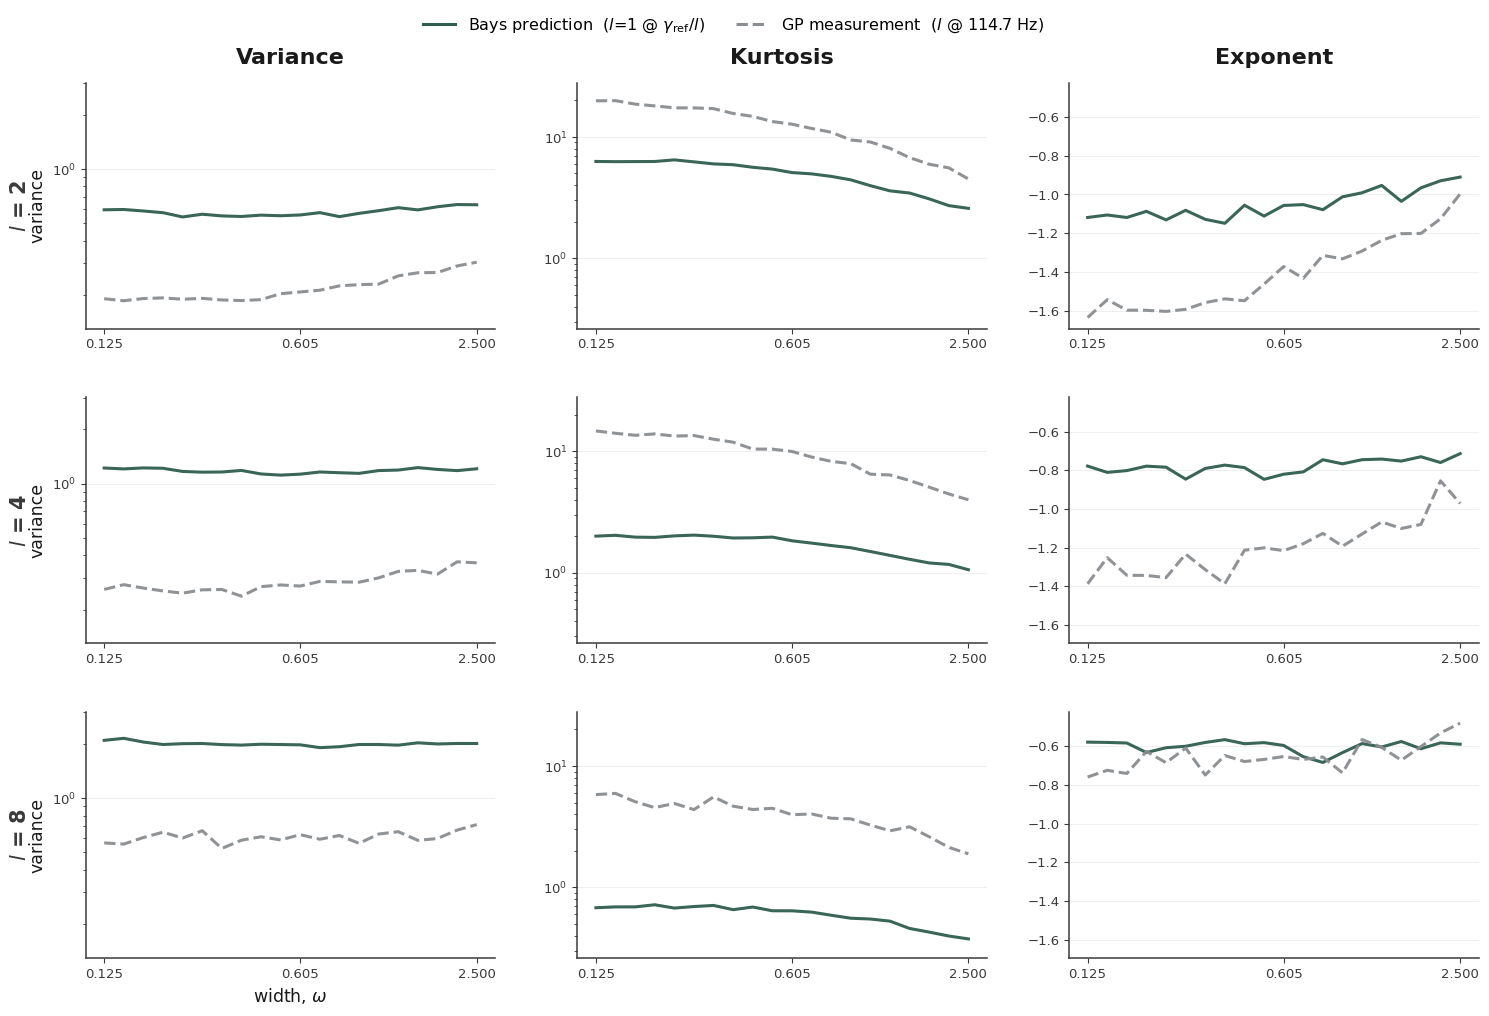

In [54]:
# ---- Visual comparison: prediction vs measurement (Candidate A) ----
#
# Columns: variance, kurtosis   |   Rows: l = 2, 4, 8
# Solid  = Bays prediction (l=1 @ γ_ref/l, interpolated)
# Dashed = GP measurement  (l @ γ_ref)

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'axes.spines.right':  False,
    'axes.spines.top':    False,
    'axes.edgecolor':     '#3a3a3a',
    'axes.linewidth':     1.1,
    'axes.labelcolor':    '#1a1a1a',
    'xtick.color':        '#3a3a3a',
    'ytick.color':        '#3a3a3a',
    'font.size':          11,
})

# Muted forest green + slate grey — calm, journal-style, grayscale-safe.
COLOR_BAYS = '#2F5D50'   # deep forest green — prediction
COLOR_GP   = '#8A8D91'   # slate grey        — measurement

quantities = [('variance', 'var'), ('kurtosis', 'kur'), ('exponent', 'exp')]
set_sizes_compare = [2, 4, 8]
ncols             = len(quantities)
nrows             = len(set_sizes_compare)

fig = plt.figure(figsize=(5.4 * ncols, 3.6 * nrows))
gs  = fig.add_gridspec(
    nrows, ncols,
    hspace=0.28, wspace=0.20,
    left=0.10, right=0.96, top=0.90, bottom=0.09,
)

# Thin the x-ticks: show only first, middle-ish, last of the omega range.
_xtick_vals = [omegas[0], omegas[len(omegas) // 2], omegas[-1]]

for col_idx, (q_name, q_key) in enumerate(quantities):
    is_exponent = (q_key == 'exp')   # exponent column: linear, signed

    all_vals = []
    for l in set_sizes_compare:
        r = next(rr for rr in results_table if rr['l'] == l)
        all_vals.append(r[f'{q_name}_pred'])
        all_vals.append(r[f'{q_name}_meas'])
    all_vals = np.concatenate(all_vals)
    all_vals = all_vals[np.isfinite(all_vals)]

    if is_exponent:
        # Signed values -> pad the raw range, no positivity filter.
        span = np.nanmax(all_vals) - np.nanmin(all_vals)
        pad  = 0.05 * span if span > 0 else 0.1
        lo   = np.nanmin(all_vals) - pad
        hi   = np.nanmax(all_vals) + pad
    else:
        pos = all_vals[all_vals > 0]
        lo  = np.nanmin(pos) * 0.7
        hi  = np.nanmax(all_vals) * 1.4

    for row_idx, l in enumerate(set_sizes_compare):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        r        = next(rr for rr in results_table if rr['l'] == l)
        vec_pred = r[f'{q_name}_pred']
        vec_meas = r[f'{q_name}_meas']

        ax.plot(omegas, vec_pred, color=COLOR_BAYS, linestyle='-',
                linewidth=2.2, alpha=0.95, zorder=3)
        ax.plot(omegas, vec_meas, color=COLOR_GP, linestyle='--',
                linewidth=2.2, alpha=0.95, zorder=3)

        ax.set_xscale('log', base=2)
        if not is_exponent:
            ax.set_yscale('log')     # keep log for variance/kurtosis only
        ax.set_ylim(lo, hi)

        ax.set_xticks(_xtick_vals)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.ticklabel_format(axis='x', style='plain')

        ax.grid(True, axis='y', which='major',
                linestyle='-', linewidth=0.6, color='#ECECEC')
        ax.set_axisbelow(True)

        if row_idx == nrows - 1 and col_idx == 0:
            ax.set_xlabel(r'width, $\omega$', fontsize=12.5)
        if col_idx == 0:
            ax.set_ylabel(q_name, fontsize=12.5)
        ax.tick_params(labelsize=9.5)

        if row_idx == 0:
            ax.set_title(q_name.capitalize(), fontsize=16,
                         fontweight='bold', pad=14, color='#1a1a1a')

        if col_idx == 0:
            ax.text(
                -0.16, 0.5, f'$l$ = {l}',
                transform=ax.transAxes, fontsize=15,
                fontweight='bold', va='center', ha='center',
                rotation=90, color='#3a3a3a',
            )
            

# ---- Single shared legend across the top ----
legend_handles = [
    mpl.lines.Line2D([], [], color=COLOR_BAYS, linestyle='-', linewidth=2.2,
                     label=r'Bays prediction  ($l$=1 @ $\gamma_{\mathrm{ref}}/l$)'),
    mpl.lines.Line2D([], [], color=COLOR_GP, linestyle='--', linewidth=2.2,
                     label=rf'GP measurement  ($l$ @ {gamma_ref:.1f} Hz)'),
]
fig.legend(
    handles=legend_handles, loc='upper center',
    bbox_to_anchor=(0.5, 0.975), ncol=2, frameon=False, fontsize=11.5,
)

_results_dir = OUTPUT_DIR
_cA_path = _results_dir / f'fig1_equivalence_candA_{MODEL}_M{M}_{DISTRIBUTION}.png'
plt.savefig(_cA_path, dpi=150, bbox_inches='tight')
print(f'Saved {_cA_path}')
plt.show()

#### Save results to CSV

Persists each equivalence result (one row per set size × metric) from `results_table` to a CSV,
tagged with a per-run `uuid` and the run configuration (`M`, `DISTRIBUTION` + `N_HIGH`, `MODEL`, `N_TRIALS`).
Rows are appended to a cumulative log at `result_data/experiment_1/fit_log.csv`, and a standalone copy is
written into this run's timestamped `OUTPUT_DIR`.

(These are equivalence statistics — Pearson ρ, MAE, rMAE — not fitted parameters; figure 1 fits nothing.)


In [55]:
# ---- Save fits + run metadata to CSV ----
#
# One row per (set size l, metric) from the quantitative-equivalence
# `results_table` above, tagged with a UUID identifying this run and the
# key configuration (population size M, lengthscale distribution + its
# N_HIGH knob, and trial count). Appended to a cumulative fits_log.csv and
# also dropped as a standalone file in this run's OUTPUT_DIR.

import uuid
import datetime as _dt
import pandas as pd

RUN_UUID = str(uuid.uuid4())
_timestamp = _dt.datetime.now().isoformat(timespec='seconds')

# N_HIGH only applies to the sparse-broad sampler; record it when present.
_n_high = N_HIGH if DISTRIBUTION == 'M_sparse_broad' else np.nan

_quantities = [('variance', 'var'), ('kurtosis', 'kur'), ('exponent', 'exp')]

_fit_rows = []
for r in results_table:
    for q_name, q_key in _quantities:
        _fit_rows.append({
            'uuid':         RUN_UUID,
            'timestamp':    _timestamp,
            'M':            M,
            'distribution': DISTRIBUTION,
            'n_high':       _n_high,
            'n_trials':     N_TRIALS,
            'model':        MODEL,
            'gamma_ref':    gamma_ref,
            'set_size':     r['l'],
            'g_eff':        r['g_eff'],
            'metric':       q_name,
            'corr':         r[f'{q_name}_corr'],
            'pval':         r[f'{q_name}_pval'],
            'mae':          r[f'{q_name}_mae'],
            'rmae':         r[f'{q_name}_rmae'],
        })

fits_df = pd.DataFrame(_fit_rows)

# Standalone copy for this run.
_run_csv = OUTPUT_DIR / f'fits_{RUN_UUID[:8]}.csv'
fits_df.to_csv(_run_csv, index=False)

# Cumulative log across all runs (append; write header only if new).
_log_csv = RESULT_BASE / EXPERIMENT_TAG / 'fit_log.csv'
_log_csv.parent.mkdir(parents=True, exist_ok=True)
_write_header = not _log_csv.exists()
fits_df.to_csv(_log_csv, mode='a', header=_write_header, index=False)

print(f"Run UUID: {RUN_UUID}")
print(f"  Wrote {len(fits_df)} fit rows")
print(f"  Run copy:   {_run_csv}")
print(f"  Appended to: {_log_csv}")
fits_df

Run UUID: 9c9682d7-9599-44a6-8385-3064950e320a
  Wrote 9 fit rows
  Run copy:   /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/figure_1_20260725_121106/fits_9c9682d7.csv
  Appended to: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/bays_2014/result_data/fits_log.csv


,uuid,timestamp,M,distribution,n_high,n_trials,tuning,gamma_ref,set_size,g_eff,metric,corr,pval,mae,rmae
0,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,2,57.365254,variance,0.770254,7.100942e-05,0.358794,0.620368
1,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,2,57.365254,kurtosis,0.978945,7.155880e-14,7.862754,1.582905
2,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,2,57.365254,exponent,0.896225,9.047020e-08,0.356066,0.337927
3,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,4,28.682627,variance,0.242362,3.032263e-01,0.890502,0.757049
4,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,4,28.682627,kurtosis,0.951752,1.128835e-10,8.086745,4.698655
5,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,4,28.682627,exponent,0.495845,2.618930e-02,0.418146,0.536904
6,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,8,14.341314,variance,-0.211637,3.703945e-01,1.390498,0.695554
7,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,8,14.341314,kurtosis,0.911925,2.192411e-08,3.456293,5.755711
8,9c9682d7-9599-44a6-8385-3064950e320a,2026-07-25T17:15:33,1000,folded_normal,NaN,10000,gp,114.730508,8,14.341314,exponent,-0.009190,9.693250e-01,0.074901,0.124602
